Saving google collab.xlsx to google collab (2).xlsx
File: google collab (2).xlsx
Shape: (300, 8)
Columns: ['DCOL-1 - Condenser_Specification_Value', "DCOL-1 - Stream 'feed' Stage Index", 'distillate - Volumetric Flow (m3/s)', 'bottiom - Volumetric Flow (m3/s)', 'distillate - Molar Fraction (Mixture) / Benzene ()', 'bottiom - Molar Fraction (Mixture) / Toluene ()', 'Qc - Energy Flow (kW)', 'Qe - Energy Flow (kW)']
Rows: 300 raw -> 300 after dropping NaN -> 300 after removing failed simulations
       reflux_ratio  feed_stage  distillate_vol_flow  bottoms_vol_flow  \
count      300.0000    300.0000             300.0000          300.0000   
mean         3.0500      9.0000               0.0000            0.0001   
std          1.1856      3.7095               0.0000            0.0000   
min          1.1000      3.0000               0.0000            0.0000   
25%          2.0750      5.5714               0.0000            0.0001   
50%          3.0500      9.0000               0.0000      

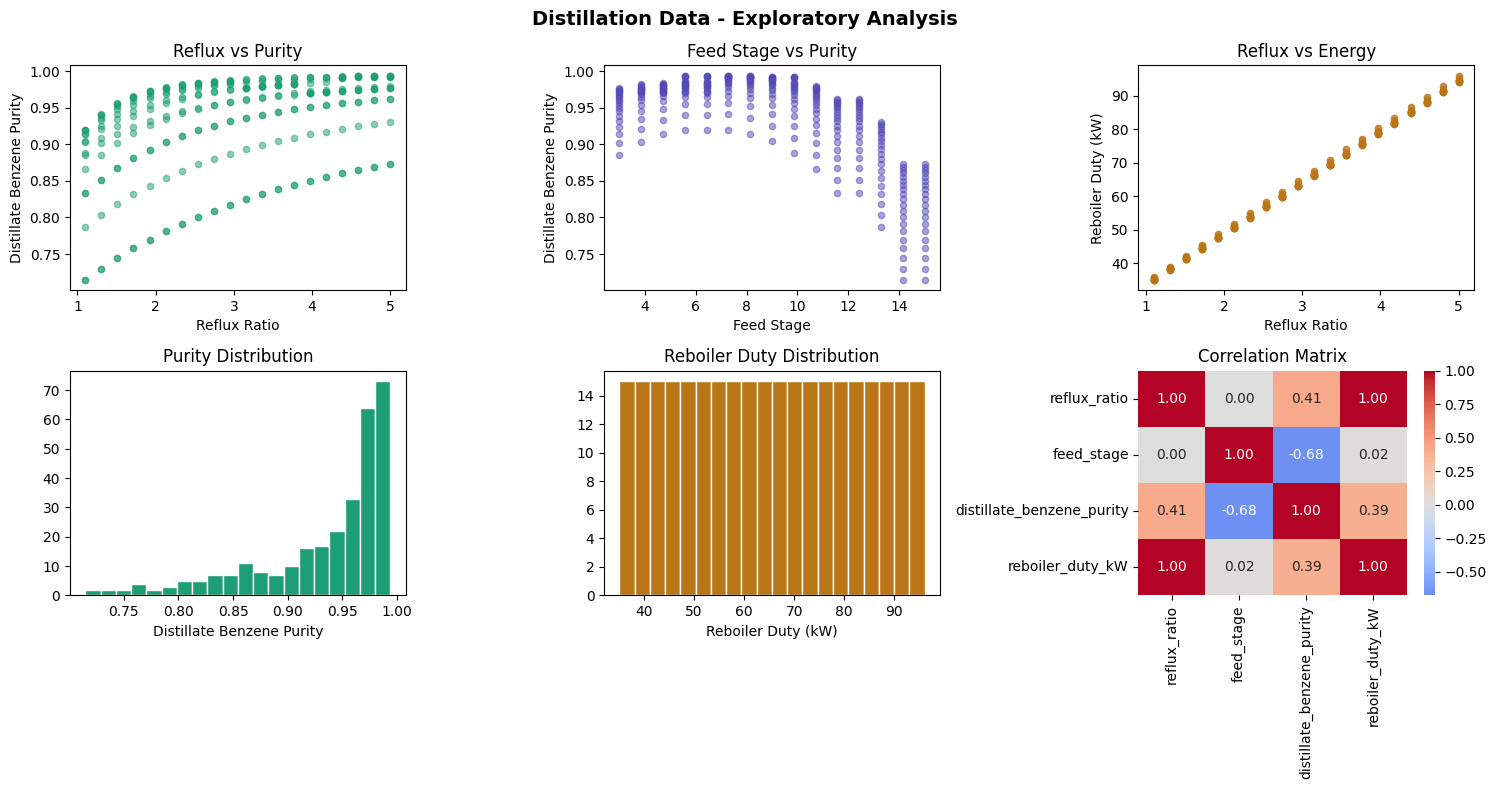

Dataset size: 300 rows | Features: ['reflux_ratio', 'feed_stage'] | Targets: ['distillate_benzene_purity', 'bottoms_toluene_purity', 'reboiler_duty_kW']

=== HOLD-OUT TEST PERFORMANCE (80/20 random split) ===
distillate_benzene_purity       R2=0.9524  MAE=0.010027
bottoms_toluene_purity          R2=0.9524  MAE=0.010032
reboiler_duty_kW                R2=1.0000  MAE=0.088859

=== 5-FOLD CROSS-VALIDATION (shuffled), per target ===
distillate_benzene_purity       R2 = 0.9507 +/- 0.0027
bottoms_toluene_purity          R2 = 0.9507 +/- 0.0027
reboiler_duty_kW                R2 = 0.9999 +/- 0.0000

=== EXTRAPOLATION CHECK (train: low reflux, test: high reflux) ===
distillate_benzene_purity       R2 = 0.6859
bottoms_toluene_purity          R2 = 0.6859
reboiler_duty_kW                R2 = -3.6595


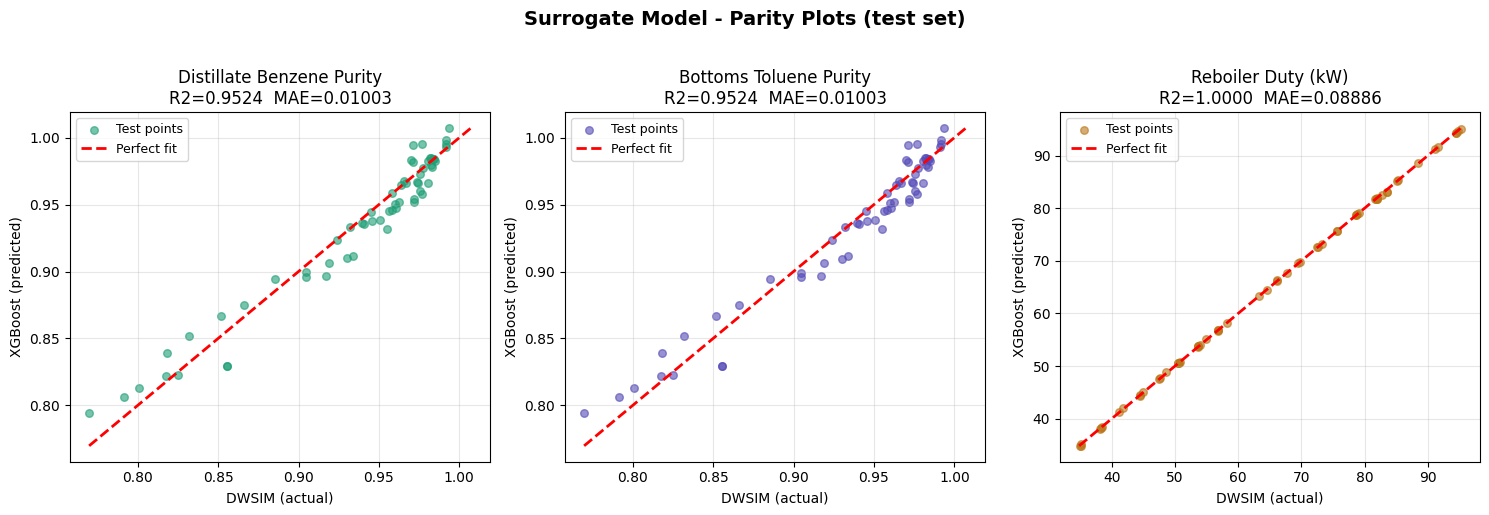

Highest purity in the training data: 0.9939 (specs above this are outside the data)

  Spec   Reflux  Stage   Duty(kW)   Purity   Met
--------------------------------------------------
  0.88    1.139      8      34.87   0.9062   yes
  0.90    1.230      8      34.87   0.9062   yes
  0.91    1.434      8      38.01   0.9256   yes
  0.92    1.402      8      38.01   0.9256   yes
  0.95    1.845      8      44.25   0.9526   yes

NEXT STEP: enter an optimum (reflux, feed stage) into DWSIM and compare the
simulator's purity and reboiler duty with the predictions above.


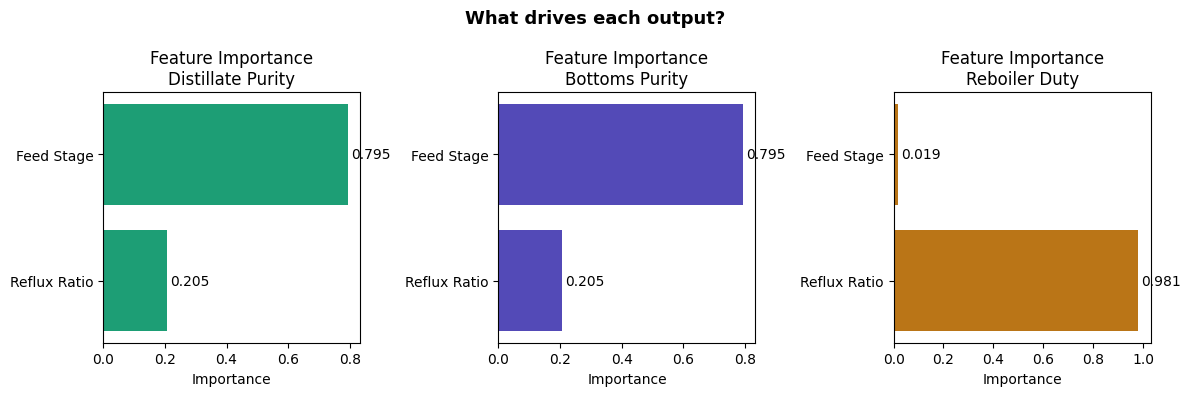

Model saved: surrogate_model.pkl
xgboost==3.4.1
scikit-learn==1.6.1
scipy==1.16.3
pandas==2.2.3
numpy==2.1.3
joblib==1.6.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import xgboost as xgb
import scipy, sklearn

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.multioutput import MultiOutputRegressor
from scipy.optimize import differential_evolution

SEED = 42

try:
    from google.colab import files
    uploaded = files.upload()
    DATA_FILE = list(uploaded.keys())[0]
except ImportError:
    DATA_FILE = "simulation_data.xlsx"

if DATA_FILE.lower().endswith(".csv"):
    df = pd.read_csv(DATA_FILE)
else:
    df = pd.read_excel(DATA_FILE)

print("File:", DATA_FILE)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


df.columns = [
    "reflux_ratio",
    "feed_stage",
    "distillate_vol_flow",
    "bottoms_vol_flow",
    "distillate_benzene_purity",
    "bottoms_toluene_purity",
    "condenser_duty_kW",
    "reboiler_duty_kW",
]

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

n_raw = len(df)
df = df.dropna()
n_after_nan = len(df)

df = df[df["distillate_benzene_purity"] > 0.5]
df = df[df["reboiler_duty_kW"] > 0]
df = df.reset_index(drop=True)

print(f"Rows: {n_raw} raw -> {n_after_nan} after dropping NaN -> {len(df)} after removing failed simulations")
print(df.describe().round(4))


fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].scatter(df["reflux_ratio"], df["distillate_benzene_purity"], alpha=0.5, color="#1D9E75", s=20)
axes[0, 0].set_xlabel("Reflux Ratio"); axes[0, 0].set_ylabel("Distillate Benzene Purity")
axes[0, 0].set_title("Reflux vs Purity")

axes[0, 1].scatter(df["feed_stage"], df["distillate_benzene_purity"], alpha=0.5, color="#534AB7", s=20)
axes[0, 1].set_xlabel("Feed Stage"); axes[0, 1].set_ylabel("Distillate Benzene Purity")
axes[0, 1].set_title("Feed Stage vs Purity")

axes[0, 2].scatter(df["reflux_ratio"], df["reboiler_duty_kW"], alpha=0.5, color="#BA7517", s=20)
axes[0, 2].set_xlabel("Reflux Ratio"); axes[0, 2].set_ylabel("Reboiler Duty (kW)")
axes[0, 2].set_title("Reflux vs Energy")

axes[1, 0].hist(df["distillate_benzene_purity"], bins=20, color="#1D9E75", edgecolor="white")
axes[1, 0].set_xlabel("Distillate Benzene Purity"); axes[1, 0].set_title("Purity Distribution")

axes[1, 1].hist(df["reboiler_duty_kW"], bins=20, color="#BA7517", edgecolor="white")
axes[1, 1].set_xlabel("Reboiler Duty (kW)"); axes[1, 1].set_title("Reboiler Duty Distribution")

corr = df[["reflux_ratio", "feed_stage", "distillate_benzene_purity", "reboiler_duty_kW"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 2], center=0)
axes[1, 2].set_title("Correlation Matrix")

plt.suptitle("Distillation Data - Exploratory Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150)
plt.show()


FEATURES = ["reflux_ratio", "feed_stage"]
TARGETS = ["distillate_benzene_purity", "bottoms_toluene_purity", "reboiler_duty_kW"]

X = df[FEATURES]
y = df[TARGETS]
print(f"Dataset size: {len(X)} rows | Features: {FEATURES} | Targets: {TARGETS}")

def make_regressor():
    return xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        random_state=SEED, verbosity=0,
    )

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

model = MultiOutputRegressor(make_regressor())
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\n=== HOLD-OUT TEST PERFORMANCE (80/20 random split) ===")
for i, col in enumerate(TARGETS):
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    print(f"{col:30s}  R2={r2:.4f}  MAE={mae:.6f}")


kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
print("\n=== 5-FOLD CROSS-VALIDATION (shuffled), per target ===")
for col in TARGETS:
    cv = cross_val_score(make_regressor(), X, df[col], cv=kf, scoring="r2")
    print(f"{col:30s}  R2 = {cv.mean():.4f} +/- {cv.std():.4f}")

cut = df["reflux_ratio"].median()
lo_mask = df["reflux_ratio"] <= cut
m_ex = MultiOutputRegressor(make_regressor()).fit(X[lo_mask], y[lo_mask])
p_ex = m_ex.predict(X[~lo_mask])
print("\n=== EXTRAPOLATION CHECK (train: low reflux, test: high reflux) ===")
for i, col in enumerate(TARGETS):
    print(f"{col:30s}  R2 = {r2_score(y[~lo_mask].iloc[:, i], p_ex[:, i]):.4f}")

# %% 6. Parity plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Distillate Benzene Purity", "Bottoms Toluene Purity", "Reboiler Duty (kW)"]
colors = ["#1D9E75", "#534AB7", "#BA7517"]

for i, (ax, title, color) in enumerate(zip(axes, titles, colors)):
    actual = y_test.iloc[:, i].values
    pred = y_pred[:, i]
    ax.scatter(actual, pred, alpha=0.6, color=color, s=30, label="Test points")
    mn, mx = min(actual.min(), pred.min()), max(actual.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect fit")
    ax.set_title(f"{title}\nR2={r2_score(actual, pred):.4f}  MAE={mean_absolute_error(actual, pred):.5f}")
    ax.set_xlabel("DWSIM (actual)"); ax.set_ylabel("XGBoost (predicted)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle("Surrogate Model - Parity Plots (test set)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("parity_plots.png", dpi=150, bbox_inches="tight")
plt.show()

LO = X.min().values
HI = X.max().values

def predict_point(reflux, feed_stage):
    p = model.predict(pd.DataFrame([[reflux, feed_stage]], columns=FEATURES))[0]
    return {"distillate_purity": float(p[0]), "bottoms_purity": float(p[1]), "reboiler_duty_kW": float(p[2])}

def optimize_column(purity_spec=0.92):
    def cost(x):
        p = predict_point(x[0], x[1])                     # one prediction per evaluation
        if p["distillate_purity"] >= purity_spec:
            return p["reboiler_duty_kW"]
        return 1e6 + (purity_spec - p["distillate_purity"]) * 1e5   # penalty if spec violated

    res = differential_evolution(
        cost, bounds=list(zip(LO, HI)), integrality=[False, True],
        seed=SEED, maxiter=200, polish=False,
    )
    p = predict_point(res.x[0], res.x[1])
    return {
        "purity_spec": purity_spec,
        "optimal_reflux": round(float(res.x[0]), 3),
        "optimal_feed_stage": int(round(res.x[1])),
        "predicted_reboiler_kW": round(p["reboiler_duty_kW"], 2),
        "predicted_distillate_purity": round(p["distillate_purity"], 4),
        "predicted_bottoms_purity": round(p["bottoms_purity"], 4),
        "spec_met": p["distillate_purity"] >= purity_spec,
    }

max_purity = df["distillate_benzene_purity"].max()
print(f"Highest purity in the training data: {max_purity:.4f} (specs above this are outside the data)\n")
print(f"{'Spec':>6} {'Reflux':>8} {'Stage':>6} {'Duty(kW)':>10} {'Purity':>8} {'Met':>5}")
print("-" * 50)
for spec in [0.88, 0.90, 0.91, 0.92, 0.95]:
    r = optimize_column(spec)
    print(f"{r['purity_spec']:>6.2f} {r['optimal_reflux']:>8.3f} {r['optimal_feed_stage']:>6d} "
          f"{r['predicted_reboiler_kW']:>10.2f} {r['predicted_distillate_purity']:>8.4f} "
          f"{'yes' if r['spec_met'] else 'NO':>5}")

print("\nNEXT STEP: enter an optimum (reflux, feed stage) into DWSIM and compare the")
print("simulator's purity and reboiler duty with the predictions above.")

# %% 8. Feature importance
feat_names = ["Reflux Ratio", "Feed Stage"]
target_names = ["Distillate Purity", "Bottoms Purity", "Reboiler Duty"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (ax, name, color) in enumerate(zip(axes, target_names, colors)):
    imp = model.estimators_[i].feature_importances_
    ax.barh(feat_names, imp, color=color)
    ax.set_title(f"Feature Importance\n{name}")
    ax.set_xlabel("Importance")
    for j, v in enumerate(imp):
        ax.text(v + 0.01, j, f"{v:.3f}", va="center")
plt.suptitle("What drives each output?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

# %% 9. Save model and record library versions (pin these in requirements.txt for Streamlit)
joblib.dump(model, "surrogate_model.pkl")
print("Model saved: surrogate_model.pkl")

try:
    from google.colab import files
    for f in ["surrogate_model.pkl", "parity_plots.png", "eda_plots.png", "feature_importance.png"]:
        files.download(f)
except ImportError:
    pass